#### 13- Datasetet “hr_employee_data.xlsx” innehåller data kopplat till ett företags anställda. Gör en EDA och tillhörande analys, föreställ dig att ledningsgruppen på ett företag ska ta del av analysen. I denna uppgift ska ingen ML-modellering göras (det kommer göras i nästa kapitel). Syftet är dels att träna på att genomföra analyser dels att demonstrera hur mycket man kan göra även utan ML-modellering.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# läsa in data
df = pd.read_excel('hr_employee_data.xlsx')
df

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...,...
14994,IND40221,0.40,0.57,2,151,3,0,1,0,support,low
14995,IND24196,0.37,0.48,2,160,3,0,1,0,support,low
14996,IND33544,0.37,0.53,2,143,3,0,1,0,support,low
14997,IND40533,0.11,0.96,6,280,4,0,1,0,support,low


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB


### 14999 observationer och inga saknade värden

In [24]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


## EXPLORATORY DATA ANALYSIS - HR EMPLOYEE DATA

### Syfte: Ge ledningsgruppen en detaljerad analys av företagets personaldata

In [25]:
# Visa kolumn namn
print("Kolumner i datasetet:")
print(df.columns.tolist())
print(f"\nDataset form: {df.shape}")

Kolumner i datasetet:
['Emp_Id', 'satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'Department', 'salary']

Dataset form: (14999, 11)


---
## 1. DATAKVALITET OCH GRUNDLÄGGANDE STATISTIK

In [26]:
# Undersök saknade värden
print("Saknade värden per kolumn:")
print(df.isnull().sum())
print(f"\nTotal saknade värden: {df.isnull().sum().sum()}")

# Duplicerade rader
print(f"Duplicerade rader: {df.duplicated().sum()}")

Saknade värden per kolumn:
Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Total saknade värden: 0
Duplicerade rader: 0


In [27]:
# Datatyper och grundläggande info
print("\n=== DATAKVALITET ===")
print(df.dtypes)
print(f"\nTotal observationer: {len(df)}")
print(f"Totala kolumner: {len(df.columns)}")


=== DATAKVALITET ===
Emp_Id                       str
satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                   str
salary                       str
dtype: object

Total observationer: 14999
Totala kolumner: 11


---
## 2. PERSONALFÖRDELNING OCH DEMOGRAFI

In [28]:
# Departmentfördelning
if 'Department' in df.columns:
    print("\n=== DEPARTMENTFÖRDELNING ===")
    dept_dist = df['Department'].value_counts()
    print(dept_dist)
    print(f"\nProcentuell fördelning:")
    print((df['Department'].value_counts(normalize=True) * 100).round(2))


=== DEPARTMENTFÖRDELNING ===
Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

Procentuell fördelning:
Department
sales          27.60
technical      18.13
support        14.86
IT              8.18
product_mng     6.01
marketing       5.72
RandD           5.25
accounting      5.11
hr              4.93
management      4.20
Name: proportion, dtype: float64


In [29]:
# Lönkategorier per department
if 'salary' in df.columns and 'Department' in df.columns:
    print("\n=== LÖNFÖRDELNING PER DEPARTMENT ===")
    salary_by_dept = pd.crosstab(df['Department'], df['salary'], margins=True)
    print(salary_by_dept)


=== LÖNFÖRDELNING PER DEPARTMENT ===
salary       high   low  medium    All
Department                            
IT             83   609     535   1227
RandD          51   364     372    787
accounting     74   358     335    767
hr             45   335     359    739
management    225   180     225    630
marketing      80   402     376    858
product_mng    68   451     383    902
sales         269  2099    1772   4140
support       141  1146     942   2229
technical     201  1372    1147   2720
All          1237  7316    6446  14999


In [30]:
# Arbetstimmar
if 'average_montly_hours' in df.columns:
    print("\n=== GENOMSNITTLIGA ARBETSTIMMAR ===")
    print(f"Medel: {df['average_montly_hours'].mean():.1f} timmar/månad")
    print(f"Median: {df['average_montly_hours'].median():.1f} timmar/månad")
    print(f"Intervall: {df['average_montly_hours'].min()} - {df['average_montly_hours'].max()} timmar/månad")


=== GENOMSNITTLIGA ARBETSTIMMAR ===
Medel: 201.1 timmar/månad
Median: 200.0 timmar/månad
Intervall: 96 - 310 timmar/månad


---
## 3. VISUALISERING AV PERSONALFÖRDELNING

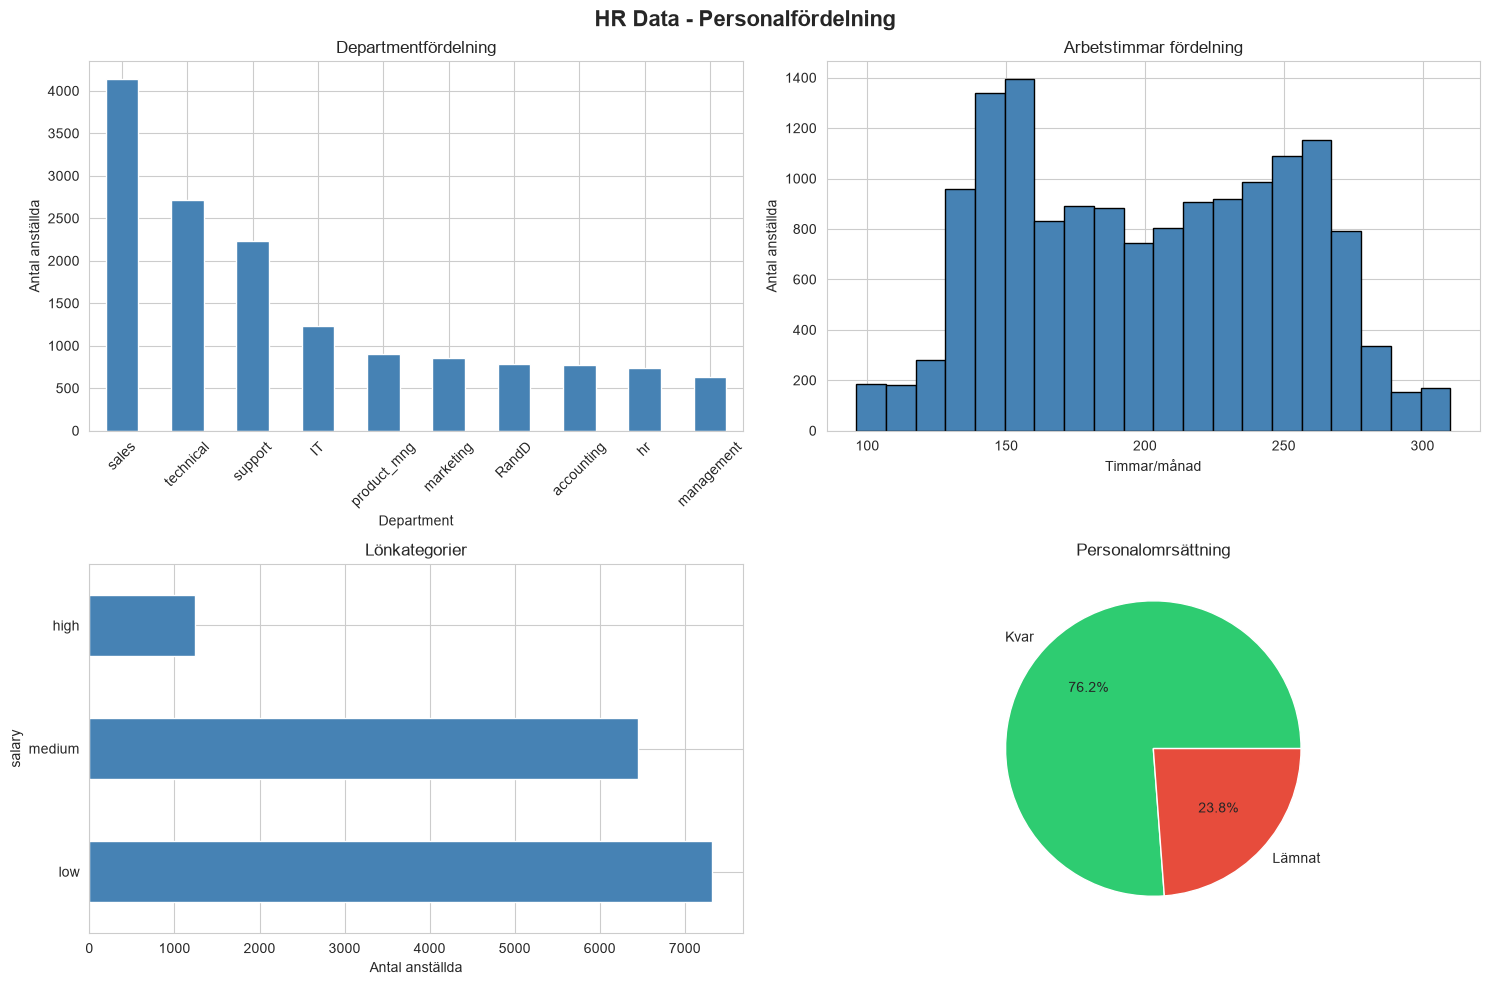

Grafer skapade


In [31]:
# Sätt style för grafer
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('HR Data - Personalfördelning', fontsize=16, fontweight='bold')

# Department
if 'Department' in df.columns:
    df['Department'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('Departmentfördelning')
    axes[0, 0].set_xlabel('Department')
    axes[0, 0].set_ylabel('Antal anställda')
    axes[0, 0].tick_params(axis='x', rotation=45)

# Arbetstimmar fördelning
if 'average_montly_hours' in df.columns:
    axes[0, 1].hist(df['average_montly_hours'], bins=20, color='steelblue', edgecolor='black')
    axes[0, 1].set_title('Arbetstimmar fördelning')
    axes[0, 1].set_xlabel('Timmar/månad')
    axes[0, 1].set_ylabel('Antal anställda')

# Lönkategorier fördelning
if 'salary' in df.columns:
    df['salary'].value_counts().plot(kind='barh', ax=axes[1, 0], color='steelblue')
    axes[1, 0].set_title('Lönkategorier')
    axes[1, 0].set_xlabel('Antal anställda')

# Attrition (left) if available
if 'left' in df.columns:
    attrition_counts = df['left'].value_counts()
    colors_att = ['#2ecc71', '#e74c3c']
    labels_att = ['Kvar', 'Lämnat'] if attrition_counts.index[0] == 0 else ['Lämnat', 'Kvar']
    axes[1, 1].pie(attrition_counts, labels=labels_att, autopct='%1.1f%%', colors=colors_att)
    axes[1, 1].set_title('Personalomrsättning')

plt.tight_layout()
plt.show()

print("Grafer skapade")

---
## 4. LÖNANALYS OCH KOMPENSATION

In [32]:
# Lönanalys
if 'salary' in df.columns:
    print("\n=== LÖNSTATISTIK ===")
    salary_dist = df['salary'].value_counts()
    print(salary_dist)
    print(f"\nProcentuell fördelning:")
    print((df['salary'].value_counts(normalize=True) * 100).round(2))


=== LÖNSTATISTIK ===
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

Procentuell fördelning:
salary
low       48.78
medium    42.98
high       8.25
Name: proportion, dtype: float64


In [33]:
# Satisfaction level analysis
if 'satisfaction_level' in df.columns:
    print("\n=== JOBBTILLFREDSSTÄLLELSE ===")
    print(f"Medel: {df['satisfaction_level'].mean():.2f}")
    print(f"Median: {df['satisfaction_level'].median():.2f}")
    print(f"Intervall: {df['satisfaction_level'].min():.2f} - {df['satisfaction_level'].max():.2f}")


=== JOBBTILLFREDSSTÄLLELSE ===
Medel: 0.61
Median: 0.64
Intervall: 0.09 - 1.00


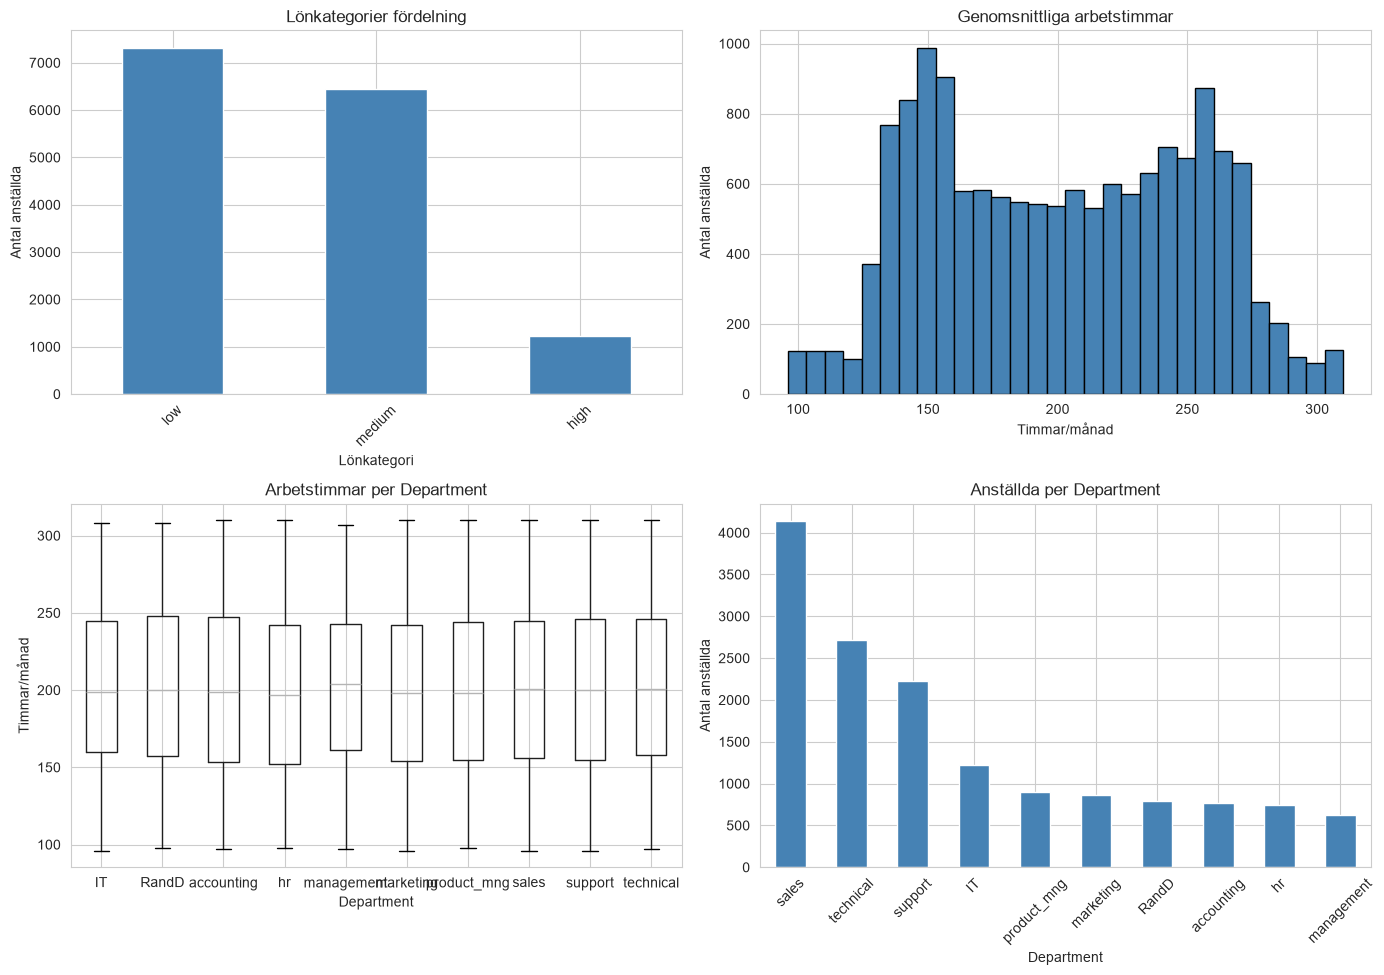

Kompensations- och arbetstidsgrafer skapade


In [34]:
# Visualisering av kompensation och arbetstid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Kompensation och Arbetstid Analys', fontsize=14, fontweight='bold')

# Lönfördelning
if 'salary' in df.columns:
    df['salary'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('Lönkategorier fördelning')
    axes[0, 0].set_xlabel('Lönkategori')
    axes[0, 0].set_ylabel('Antal anställda')
    axes[0, 0].tick_params(axis='x', rotation=45)

# Arbetstimmar fördelning
if 'average_montly_hours' in df.columns:
    axes[0, 1].hist(df['average_montly_hours'], bins=30, color='steelblue', edgecolor='black')
    axes[0, 1].set_title('Genomsnittliga arbetstimmar')
    axes[0, 1].set_xlabel('Timmar/månad')
    axes[0, 1].set_ylabel('Antal anställda')

# Arbetstimmar per department
if 'average_montly_hours' in df.columns and 'Department' in df.columns:
    df.boxplot(column='average_montly_hours', by='Department', ax=axes[1, 0])
    axes[1, 0].set_title('Arbetstimmar per Department')
    axes[1, 0].set_xlabel('Department')
    axes[1, 0].set_ylabel('Timmar/månad')
    plt.suptitle('')

# Anställda per Department
if 'Department' in df.columns:
    df['Department'].value_counts().plot(kind='bar', ax=axes[1, 1], color='steelblue')
    axes[1, 1].set_title('Anställda per Department')
    axes[1, 1].set_xlabel('Department')
    axes[1, 1].set_ylabel('Antal anställda')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Kompensations- och arbetstidsgrafer skapade")


---
## 5. ANSTÄLLNINGSTID OCH KARRIÄRUTVECKLING

In [35]:
# Anställningstid (time_spend_company)
if 'time_spend_company' in df.columns:
    print("\n=== ANSTÄLLNINGSTID ===")
    print(f"Genomsnittlig anställningstid: {df['time_spend_company'].mean():.1f} år")
    print(f"Mediananställningstid: {df['time_spend_company'].median():.1f} år")
    print(f"Anställningstid intervall: {df['time_spend_company'].min()} - {df['time_spend_company'].max()} år")
    print(f"\nAnställningslängd distribution:")
    print(df['time_spend_company'].value_counts().sort_index())


=== ANSTÄLLNINGSTID ===
Genomsnittlig anställningstid: 3.5 år
Mediananställningstid: 3.0 år
Anställningstid intervall: 2 - 10 år

Anställningslängd distribution:
time_spend_company
2     3244
3     6443
4     2557
5     1473
6      718
7      188
8      162
10     214
Name: count, dtype: int64


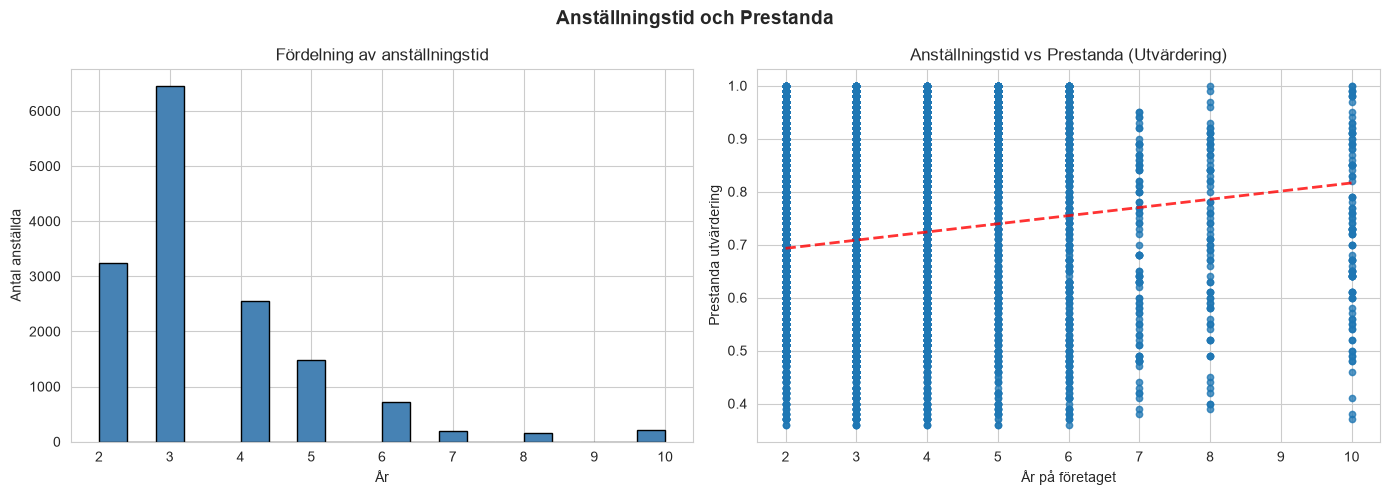

In [36]:
# Karriärsituation - anställningstid och prestanda
if 'time_spend_company' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Anställningstid och Prestanda', fontsize=14, fontweight='bold')
    
    # Histogram
    axes[0].hist(df['time_spend_company'], bins=20, color='steelblue', edgecolor='black')
    axes[0].set_title('Fördelning av anställningstid')
    axes[0].set_xlabel('År')
    axes[0].set_ylabel('Antal anställda')
    
    # Relation mellan anställningstid och utvärdering
    if 'last_evaluation' in df.columns:
        axes[1].scatter(df['time_spend_company'], df['last_evaluation'], alpha=0.5, s=20)
        axes[1].set_title('Anställningstid vs Prestanda (Utvärdering)')
        axes[1].set_xlabel('År på företaget')
        axes[1].set_ylabel('Prestanda utvärdering')
        # Lägg till trend line
        z = np.polyfit(df['time_spend_company'], df['last_evaluation'], 1)
        p = np.poly1d(z)
        axes[1].plot(df['time_spend_company'].sort_values(), p(df['time_spend_company'].sort_values()), "r--", alpha=0.8, linewidth=2)
    
    plt.tight_layout()
    plt.show()

---
## 6. PRESTANDA OCH JOBBSATISFAKTION

In [37]:
# Prestanda och tillfredsställelse metriker
if 'last_evaluation' in df.columns:
    print("\n=== PRESTANDA (Utvärdering) ===")
    print(f"Medel: {df['last_evaluation'].mean():.2f}")
    print(f"Median: {df['last_evaluation'].median():.2f}")
    print(f"Intervall: {df['last_evaluation'].min():.2f} - {df['last_evaluation'].max():.2f}")

if 'satisfaction_level' in df.columns:
    print("\n=== JOBBTILLFREDSSTÄLLELSE ===")
    print(f"Medel: {df['satisfaction_level'].mean():.2f}")
    print(f"Median: {df['satisfaction_level'].median():.2f}")
    print(f"Intervall: {df['satisfaction_level'].min():.2f} - {df['satisfaction_level'].max():.2f}")


=== PRESTANDA (Utvärdering) ===
Medel: 0.72
Median: 0.72
Intervall: 0.36 - 1.00

=== JOBBTILLFREDSSTÄLLELSE ===
Medel: 0.61
Median: 0.64
Intervall: 0.09 - 1.00


In [38]:
# Prestanda och tillfredsställelse metriker
if 'last_evaluation' in df.columns:
    print("\n=== PRESTANDA (Utvärdering) ===")
    print(f"Medel: {df['last_evaluation'].mean():.2f}")
    print(f"Median: {df['last_evaluation'].median():.2f}")
    print(f"Intervall: {df['last_evaluation'].min():.2f} - {df['last_evaluation'].max():.2f}")

if 'satisfaction_level' in df.columns:
    print("\n=== JOBBTILLFREDSSTÄLLELSE ===")
    print(f"Medel: {df['satisfaction_level'].mean():.2f}")
    print(f"Median: {df['satisfaction_level'].median():.2f}")
    print(f"Intervall: {df['satisfaction_level'].min():.2f} - {df['satisfaction_level'].max():.2f}")


=== PRESTANDA (Utvärdering) ===
Medel: 0.72
Median: 0.72
Intervall: 0.36 - 1.00

=== JOBBTILLFREDSSTÄLLELSE ===
Medel: 0.61
Median: 0.64
Intervall: 0.09 - 1.00


---
## 7. PERSONALOMRSÄTTNING (ATTRITION ANALYSIS)

In [39]:
# Attrition analys (left column)
if 'left' in df.columns:
    print("\n=== PERSONALOMRSÄTTNING ===")
    attrition_dist = df['left'].value_counts()
    print(f"Kvar på företaget: {attrition_dist.get(0, 0)}")
    print(f"Lämnat företaget: {attrition_dist.get(1, 0)}")
    attrition_rate = (df['left'] == 1).sum() / len(df) * 100
    print(f"\nPersonalomrsättningsgrad: {attrition_rate:.2f}%")
    
    # Attrition per department
    print("\n=== PERSONALOMRSÄTTNING PER DEPARTMENT ===")
    if 'Department' in df.columns:
        attrition_by_dept = pd.crosstab(df['Department'], df['left'], normalize='index') * 100
        print(attrition_by_dept.round(2))


=== PERSONALOMRSÄTTNING ===
Kvar på företaget: 11428
Lämnat företaget: 3571

Personalomrsättningsgrad: 23.81%

=== PERSONALOMRSÄTTNING PER DEPARTMENT ===
left             0      1
Department               
IT           77.75  22.25
RandD        84.63  15.37
accounting   73.40  26.60
hr           70.91  29.09
management   85.56  14.44
marketing    76.34  23.66
product_mng  78.05  21.95
sales        75.51  24.49
support      75.10  24.90
technical    74.38  25.62


In [40]:
# Faktorer relaterade till attrition
if 'Attrition' in df.columns:
    print("\n=== GENOMSNITTLIG LÖN - ATTRITION JÄMFÖRELSE ===")
    if 'MonthlyIncome' in df.columns:
        attrition_salary = df.groupby('Attrition')['MonthlyIncome'].agg(['mean', 'median', 'count'])
        print(attrition_salary.round(0))
    
    print("\n=== GENOMSNITTLIG ANSTÄLLNINGSTID - ATTRITION JÄMFÖRELSE ===")
    if 'YearsAtCompany' in df.columns:
        attrition_years = df.groupby('Attrition')['YearsAtCompany'].agg(['mean', 'median', 'count'])
        print(attrition_years.round(2))

---
## 8. ÖVERGRIPANDE INSIKTER OCH REKOMMENDATIONER

In [41]:
print("="*60)
print("KEY INSIGHTS - SAMMANFATTNING FÖR LEDNINGSGRUPPEN")
print("="*60)

# 1. Personalstyrka
print(f"\n1. PERSONALSTYRKA:")
print(f"   - Total antal anställda: {len(df):,}")
if 'Department' in df.columns:
    print(f"   - Departments: {df['Department'].nunique()}")
    largest_dept = df['Department'].value_counts().index[0]
    print(f"   - Största department: {largest_dept} ({df['Department'].value_counts().iloc[0]} anställda)")

# 2. Arbetstid
if 'average_montly_hours' in df.columns:
    print(f"\n2. ARBETSTID:")
    print(f"   - Genomsnittlig arbetstid: {df['average_montly_hours'].mean():.1f} timmar/månad")
    print(f"   - Arbetstidsspridning: {df['average_montly_hours'].min():.0f} - {df['average_montly_hours'].max():.0f} timmar/månad")

# 3. Kompensation
if 'salary' in df.columns:
    print(f"\n3. KOMPENSATION:")
    print(f"   - Lönfördelning:")
    salary_counts = df['salary'].value_counts()
    for sal_level, count in salary_counts.items():
        pct = count/len(df)*100
        print(f"     • {sal_level}: {count} anställda ({pct:.1f}%)")

# 4. Anställningstid
if 'time_spend_company' in df.columns:
    print(f"\n4. ANSTÄLLNINGSTID:")
    print(f"   - Genomsnittlig anställningstid: {df['time_spend_company'].mean():.1f} år")
    long_term = (df['time_spend_company'] >= 5).sum()
    print(f"   - Långtidsanställda (≥5 år): {long_term} ({long_term/len(df)*100:.1f}%)")

# 5. Personalomrsättning
if 'left' in df.columns:
    attrition_rate = (df['left'] == 1).sum() / len(df) * 100
    print(f"\n5. PERSONALOMRSÄTTNING:")
    print(f"   - Omrsättningsgrad: {attrition_rate:.2f}%")
    print(f"   - Anställda som lämnat: {(df['left'] == 1).sum()}")
    print(f"   - Befintlig personal: {(df['left'] == 0).sum()}")

# 6. Prestanda och Tillfredsställelse
if 'satisfaction_level' in df.columns:
    print(f"\n6. PRESTANDA OCH TILLFREDSSTÄLLELSE:")
    print(f"   - Genomsnittlig tillfredsställelse: {df['satisfaction_level'].mean():.2f}")
    if 'last_evaluation' in df.columns:
        print(f"   - Genomsnittlig prestanda: {df['last_evaluation'].mean():.2f}")

print("\n" + "="*60)

KEY INSIGHTS - SAMMANFATTNING FÖR LEDNINGSGRUPPEN

1. PERSONALSTYRKA:
   - Total antal anställda: 14,999
   - Departments: 10
   - Största department: sales (4140 anställda)

2. ARBETSTID:
   - Genomsnittlig arbetstid: 201.1 timmar/månad
   - Arbetstidsspridning: 96 - 310 timmar/månad

3. KOMPENSATION:
   - Lönfördelning:
     • low: 7316 anställda (48.8%)
     • medium: 6446 anställda (43.0%)
     • high: 1237 anställda (8.2%)

4. ANSTÄLLNINGSTID:
   - Genomsnittlig anställningstid: 3.5 år
   - Långtidsanställda (≥5 år): 2755 (18.4%)

5. PERSONALOMRSÄTTNING:
   - Omrsättningsgrad: 23.81%
   - Anställda som lämnat: 3571
   - Befintlig personal: 11428

6. PRESTANDA OCH TILLFREDSSTÄLLELSE:
   - Genomsnittlig tillfredsställelse: 0.61
   - Genomsnittlig prestanda: 0.72



In [42]:
# Korrelationsanalys
print("\n=== KORRELATIONSANALYS ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols) > 1:
    correlation_matrix = df[numeric_cols].corr()
    
    # Visa starkaste korrelationer med attrition (left)
    if 'left' in correlation_matrix.columns:
        print("\nStarkaste korrelationer med Personalomrsättning (left):")
        corr_with_attrition = correlation_matrix['left'].sort_values(ascending=False)
        print(corr_with_attrition[corr_with_attrition.index != 'left'].head(10))
    
    print("\nStarkaste korrelationer med Jobbtillfredsställelse:")
    if 'satisfaction_level' in correlation_matrix.columns:
        corr_with_satisfaction = correlation_matrix['satisfaction_level'].sort_values(ascending=False)
        print(corr_with_satisfaction[corr_with_satisfaction.index != 'satisfaction_level'].head(10))


=== KORRELATIONSANALYS ===

Starkaste korrelationer med Personalomrsättning (left):
time_spend_company       0.144822
average_montly_hours     0.071287
number_project           0.023787
last_evaluation          0.006567
promotion_last_5years   -0.061788
Work_accident           -0.154622
satisfaction_level      -0.388375
Name: left, dtype: float64

Starkaste korrelationer med Jobbtillfredsställelse:
last_evaluation          0.105021
Work_accident            0.058697
promotion_last_5years    0.025605
average_montly_hours    -0.020048
time_spend_company      -0.100866
number_project          -0.142970
left                    -0.388375
Name: satisfaction_level, dtype: float64


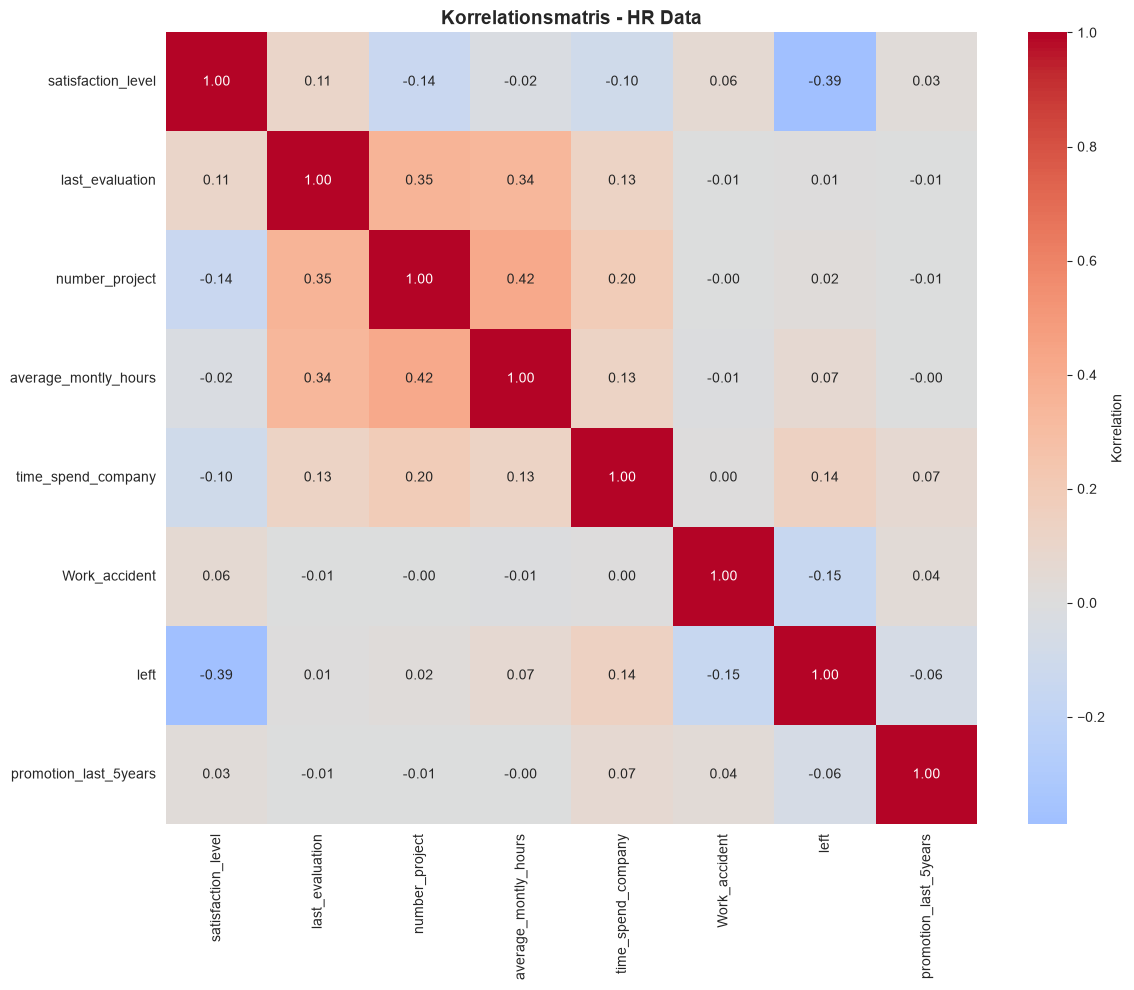


Korrelationsmatris visualiserad


In [43]:
# Heatmap för korrelationer
if len(numeric_cols) > 1:
    fig, ax = plt.subplots(figsize=(12, 10))
    correlation_matrix = df[numeric_cols].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, ax=ax, cbar_kws={'label': 'Korrelation'})
    ax.set_title('Korrelationsmatris - HR Data', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print("\nKorrelationsmatris visualiserad")

---
## 9. SLUTSATSER OCH REKOMMENDATIONER

### Rekommendationer baserat på analysen:

1. **Personalomrsättning**: Fokusera på att minska personalomrsättningen genom att identifiera riskgrupper
2. **Lönanalys**: Granska lönstruktur för att säkerställa rättvisa mellan departments  
3. **Långtidsanställda**: Utveckla retention-program för nyckeltalanger
4. **Tillfredsställelse**: Koppla samman jobbtillfredsställelse med prestanda för att identifiera utvecklingsomraden
5. **Karriärutveckling**: Implementera tydligare karriärvägar för att öka motivation och minska attrition